# Newspaper metadata: exploration & sampling

This notebook illustrates ways to access, filter, join and sample from a set of three CSV tables containing historical newspaper metadata released by the Living with Machines (LwM) project.

Newspaper metadata refers to information *about* the titles, issues and articles that were published, such as their place and date of publication (as opposed to the newspaper content itself). By exploring this metadata we can identify subsets of the newspaper collections of particular interest for a given research question. Given the large volume of textual data in the newspaper collections themselves, this process of sampling is an important step to focus subsequent analysis.

In the final section of the notebook a sample of metadata will be used to download the corresponding article text.

**NOTE:** This is an interactive notebook. To work properly, the cells should be executed in order from top to bottom. Most of the cells will work without any changes, but sometimes some manual intervention is needed to adapt the code (e.g. an exercise). These are highlighted with the the words "**YOUR TURN**".

#### Contents:

1. Newspaper metadata
1. Data download
1. Read CSV files
1. Summary statistics
1. Data Visualisation
1. Construct samples
   - Filtered samples
   - Impartial samples
   - Prescriptive samples
1. Full text access
1. Summary

We begin by importing some Python libraries. 

**Make sure you have selected an appropriate Jupyter kernel** using the button in the top-right corner, otherwise these import commands will produce errors.

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from tqdm import tqdm
from urllib.request import urlretrieve

pd.set_option('display.max_rows', 4)

## 1. Newspaper metadata

This notebook focuses primarily on data extracted from the LwM relational database of historical newspaper metadata ([lwmdb](https://github.com/Living-with-machines/lwmdb)).

These extracts consist of three tables, containing one row per newspaper title, issue and item (respectively):

| Table  | Rows        | Columns | Size   |
|--------|-------------|---------|--------|
| TITLES | 1,504       | 35      | 430 KB |
| ISSUES | 2,425,752   | 6       | 147 MB |
| ITEMS  | 223,012,941 | 7       | 15 GB |

The term "item" refers to a semantic unit within a newspaper page (identified during the digitisation process). Typically these are newspaper articles but they may instead be adverts or illustrations. 

Due to their large size, the number of columns in the ISSUES and ITEMS tables is minimised. Additional metadata columns can be added by joining with the TITLES table (as demonstrated below).

At 6.7 GB, the ITEMS table remains too large to work with conveniently on most personal computers. For this reason, we shall restrict our attention to a subset of newspaper items, which we refer to as "open access" because they are not subject to licensing constraints which limit access to the newspaper content.

| Table              | Rows      | Columns | Size   |
|--------------------|-----------|---------|--------|
| OPEN ACCESS ITEMS  | 9,326,170 | 7       | 616 MB |


## 2. Data download

This step only needs to be performed once, after which the downloaded metadata will be available in the `./data` subdirectory.

The CSV files will be downloaded and stored locally in the following locations:

In [ ]:
titles_csv = Path("./data/lwmdb_titles.csv")
issues_csv = Path("./data/lwmdb_issues.csv")
items_csv = Path("./data/lwmdb_items_oa.csv")

The largest CSV files are zipped in the remote storage repository and will be stored as:

In [ ]:
issues_zip = Path("./data/lwmdb_issues.zip")
items_zip = Path("./data/lwmdb_items_oa.zip")

**NOTE:** Due to the large size of the ITEMS table we will work with a subset of the data, containing only the "open access" material.

#### Check for locally-stored data

If all of the data files are already available locally, you can skip forward to [Section 3](#readcsvfiles) to read the CSV files.

Otherwise, execute the cells below to download the data.

In [91]:
all_files = [titles_csv, issues_csv, items_csv, issues_zip, items_zip]

if all(map(lambda file: file.exists(), all_files)):
    print("All data files found. Skip forward to Section 3.")
else:
    print("One or more data files were not found. Run the following cells to download data.")

One or more data files were not found. Run the following cells to download data.


#### Download the data from Zenodo

The data files are stored on the [Zenodo](https://zenodo.org/) research repository at the following URL:

In [92]:
zenodo_url = "https://zenodo.org/records/15102269/files/{FILENAME}?download=1"

Download the TITLES table:

In [93]:
if not os.path.exists(titles_csv):
    urlretrieve(zenodo_url.replace("{FILENAME}", titles_csv.name), titles_csv)

Download and unzip the ISSUES table:

In [94]:
if not os.path.exists(issues_zip):
    urlretrieve(zenodo_url.replace("{FILENAME}", issues_zip.name), issues_zip)
if not os.path.exists(issues_csv):
    !unzip -j {issues_zip} -d {Path("data")}

Archive:  data/lwmdb_issues.zip
  inflating: data/lwmdb_issues.csv   


Download and unzip the ITEMS table (note the zip file is 2.8 GB and this step may take several minutes):

In [97]:
if not os.path.exists(items_zip):
    urlretrieve(zenodo_url.replace("{FILENAME}", items_zip.name), items_zip)
if not os.path.exists(items_csv):
    !unzip -j {items_zip} -d {Path("data")}

Archive:  data/lwmdb_items_oa.zip
  inflating: data/lwmdb_items_oa.csv  


#### Check the downloaded data

If the downloads were successful, the CSV files will now be available in the `data/` subdirectory.

In [98]:
!ls -lh ./data/*.csv
if all(map(os.path.exists, (titles_csv, issues_csv, items_csv))):
    print("All CSV files found!")

-rw-rw-r--  1 thobson  staff   147M 28 Aug  2024 ./data/lwmdb_issues.csv
-rw-rw-r--  1 thobson  staff   616M 30 May  2024 ./data/lwmdb_items_oa.csv
-rw-r--r--  1 thobson  staff   414K 28 Mar 15:26 ./data/lwmdb_titles.csv
-rw-r--r--  1 thobson  staff   1.5M  1 Oct 10:13 ./data/subsample500mixedocr-selected_mitch.csv
All CSV files found!


**YOUR TURN: (Optional)**

The `data/` subdirectory should now contain three CSV files: `title_query_sorted.csv`, `issue_query_sorted.csv` and `item_query_sorted.csv`

In the next section we will read these tables as a [`pandas`](https://pandas.pydata.org/) data frames. 

But you might also want to view them in a spreadsheet application, such as Microsoft Excel or OpenOffice Calc. 

<details>
  <summary>Click here for Microsoft Excel instructions</summary>
  
You will need to use the "Import" function, to make sure the column separators are interpreted correctly.

To view the table in Excel, go to the `File` menu and choose `Import`. Select the type `CSV file`, then navigate to the `data/` subdirectory and select a CSV file, e.g. `title_query_sorted.csv`. 

On the next step, choose `Delimited` and on the following step select `Other` and enter the pipe character '|' in the box. Then click `Finish`.
</details>
</br>
<details>
  <summary>Click here for OpenOffice Calc instructions</summary>
  
To view the table in Calc, go to the `File` menu and choose `Open`. Navigate to the `data/` subdirectory and select a CSV file, e.g. `title_query_sorted.csv`. 

In the next window under `Separator options`, enter the pipe character '|' in the box next to `Other`. Also untick all other separator checkboxes. Then click `Ok`.

</details>


## 3. Read CSV files
<a id='readcsvfiles'></a>

Now that we have a local copy of the CSV files, we are ready to read in the data.

We begin by defining a function to read each of the CSV files with the correct column types.

In [99]:
def read_csv(file, int_cols=list(), float_cols=list(), date_cols=list(), **kwargs):
    df = pd.read_csv(file, dtype=str, **kwargs)
    # Remove whitespace from column names:
    df.columns = df.columns.str.replace(' ', '')
    for arg in int_cols:
        # Replace whitespace strings with NaN and convert to Int64:
        df[arg] = df[arg].str.replace(' ', '').replace('', np.nan).astype('Int64')
    for arg in float_cols:
        df[arg] = pd.to_numeric(df[arg], errors='coerce')
    for arg in date_cols:
        df[arg] = pd.to_datetime(df[arg])
    return df 

#### Read the TITLES table:

In [100]:
titles = read_csv(titles_csv, float_cols=['latitude', 'longitude'], delimiter='|')
display(titles)

,newspaper_id,newspaper_title,publication_code,location,data_provider,xml_flavour,digitisation_software,place_of_publication_id,wikidata_id,gazetteer_label,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
0,1,Lancaster Gazette,0000001,NaN,FindMyPast,alto,CCS docWORKS/METAe Version 6.3-0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Wrexham Advertiser,0000002,NaN,FindMyPast,alto,CCS docWORKS/METAe Version 6.3-0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1502,1503,The Commonwealth,0003541,"London, England",Living with Machines,alto,CCS docWorks/METAe Version 7.1-0,960,Q84,London,...,60,['radical'],radical,59,"['2d', '3d']",3d,January<SEP>1866,Saturday,[],['F. Farrah']
1503,1504,"New Tredegar, Bargoed & Caerphilly Journal",0003548,"Bedwellty, Gwent, Wales",Living with Machines,alto,CCS docWorks/METAe Version 7.1-0,605,Q2664179,Bargoed,...,NaN,[],NaN,173,['½ d'],½ d,1904,Saturdays,[],['Percy S. Phillips']


#### Read the ISSUES table:

In [101]:
issues = read_csv(issues_csv, date_cols=["date"], delimiter='|')
display(issues)

,issue_id,issue_code,date,data_provider,newspaper_id,publication_code
0,31,0000001-18020130,1802-01-30,FindMyPast,1,0000001
1,30,0000001-18020206,1802-02-06,FindMyPast,1,0000001
...,...,...,...,...,...,...
2425750,2425751,0003548-19040630,1904-06-30,Living with Machines,1504,0003548
2425751,2425752,0003548-19040707,1904-07-07,Living with Machines,1504,0003548


#### Read the ITEMS table:

**Note:** the complete ITEMS table contains 223,012,941 rows and is 15 GB in size, too large for most personal computers to store in memory. For this reason, we restrict our attention to the "open access" material. This subset of the ITEMS table contains 9,326,170 rows.

In [102]:
items = read_csv(items_csv, int_cols=['word_count'], float_cols=['ocr_quality_mean'], date_cols=["date"], delimiter='|')
display(items)

,item_id,item_code,word_count,ocr_quality_mean,issue_id,date,newspaper_id
0,199423896,0002083-18560716-art0056,187,0.8491,1910018,1856-07-16,1251
1,199425153,0002083-18560716-art0061,53,0.8858,1910018,1856-07-16,1251
...,...,...,...,...,...,...,...
9326168,223012930,0003548-19040707-art0008,10,0.6930,2425752,1904-07-07,1504
9326169,223012936,0003548-19040707-art0077,1242,0.8836,2425752,1904-07-07,1504


## 4. Summary statistics

To better understand the data, we'll calculate some summary statistics.

#### Data Providers

In the TITLES and ISSUES tables, the `data_provider` refers to the organisation that provided access to the digitised newspapers collections.

There are four data providers:
 - **FindMyPast**: a private company which publishes the [British Newspaper Archive](https://www.britishnewspaperarchive.co.uk/) subscription-based web portal.
 - **JISC**: a not-for-profit subscription service (for libraries) that directed two phases of newspaper digitisation between 2004 and 2009 with public funding.
 - **Living with Machines**: a collaborative research project involving the British Library which ran from 2018 to 2023.
 - **Heritage Made Digital**: a British Library digitisation programme.

This is an important variable in our data, because it determines the level of accessibility of the newspaper content. This content may include page images and/or text obtained from the images via Optical Character Recognition (OCR) software.

Only material from the last two data providers, Living with Machines and Heritage Made Digital, is openly accessible without subscription or special agreement.

So let's begin by counting the number of newspaper titles and issues, separately for each of the data providers:

In [103]:
title_count = titles['data_provider'].value_counts().to_frame(name = "Number of Titles")
issue_count = issues['data_provider'].value_counts().to_frame(name = "Number of Issues")
data_providers = pd.concat([title_count, issue_count], axis = 1)
data_providers.reset_index(inplace=True, names = "Data Provider")
data_providers

,Data Provider,Number of Titles,Number of Issues
0,FindMyPast,1250,1910017
1,Joint Information Systems Committee,133,408023
2,Living with Machines,107,57266
3,Heritage Made Digital,14,50446


We see that the open access material includes 107,712 issues from 121 titles (although it is only ~5% of the whole).

#### Temporal distribution

The ISSUES table includes the date of publication, ranging from 1720-05-02 to 1957-12-31.

Here we plot a histogram showing the number of issues published per decade, from 1750 to 1950.

Text(0.5, 1.0, 'Number of newspaper issues, by decade')

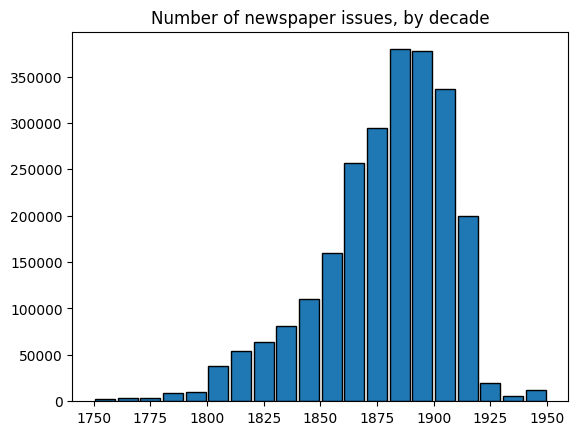

In [104]:
bins = list(range(1750, 1960, 10))
plt.hist([date.year for date in issues['date']], bins=bins, rwidth=0.88, edgecolor='black')
plt.title('Number of newspaper issues, by decade')

**YOUR TURN: (Optional)**

Plot a histogram, similar to the one above, of the temporal distribution of (open access) newspaper **items**.

<details>
  <summary>Click here for a hint.</summary>
  
**Hint:**

Copy the code in the preceding cell and paste it into a new cell below this one. 

Edit the code so that it refers to the table named `items`, instead of `issues`.

Then change the histogram title inside the `plt.title` command.
</details>

## 5. Data Visualisation

This standalone section presents an example of how we can visualise the newspaper metadata geospatially along three axes: price, place of publication and political leaning.

First we filter the TITLES table to exclude rows in which the relevant data is missing:

In [105]:
ppp = titles[~titles["price_label"].isna() & ~titles["location"].isna() & ~titles["political_leaning_label"].isna()]

Next we parse the values in the `price_label` column to obtain a numerical price column:

In [106]:
from fractions import Fraction
def parse_price_label(price_label):
    halfpenny = False
    if '½' in price_label:
        halfpenny = True
    price = price_label.strip('½ d').strip()
    if len(price) == 0:
        price = '0'
    price = Fraction(price)
    if halfpenny:
        price += Fraction(1, 2)
    return price
    
ppp.insert(column="price", value=ppp['price_label'].apply(parse_price_label), loc=ppp.columns.get_loc('price_label'))

To plot the data geospatially we'll need to read GeoJSON files containing country outlines for the UK. We also convert our data into a GeoDataFrame by attaching a column of coordinate geometry derived from the longitude and latitude columns.

In [107]:
import geopandas as gpd
from shapely.geometry import Point

england = gpd.read_file('./data/topo_england.json')
wales = gpd.read_file('./data/topo_wales.json')
scotland = gpd.read_file('./data/topo_scotland.json')
northern_ireland = gpd.read_file('./data/topo_ni.json')

geometry = [Point(xy) for xy in zip(ppp['longitude'], ppp['latitude'])]
geo_df = gpd.GeoDataFrame(ppp, geometry=geometry)

We're now ready to plot the geospatial visualisation:

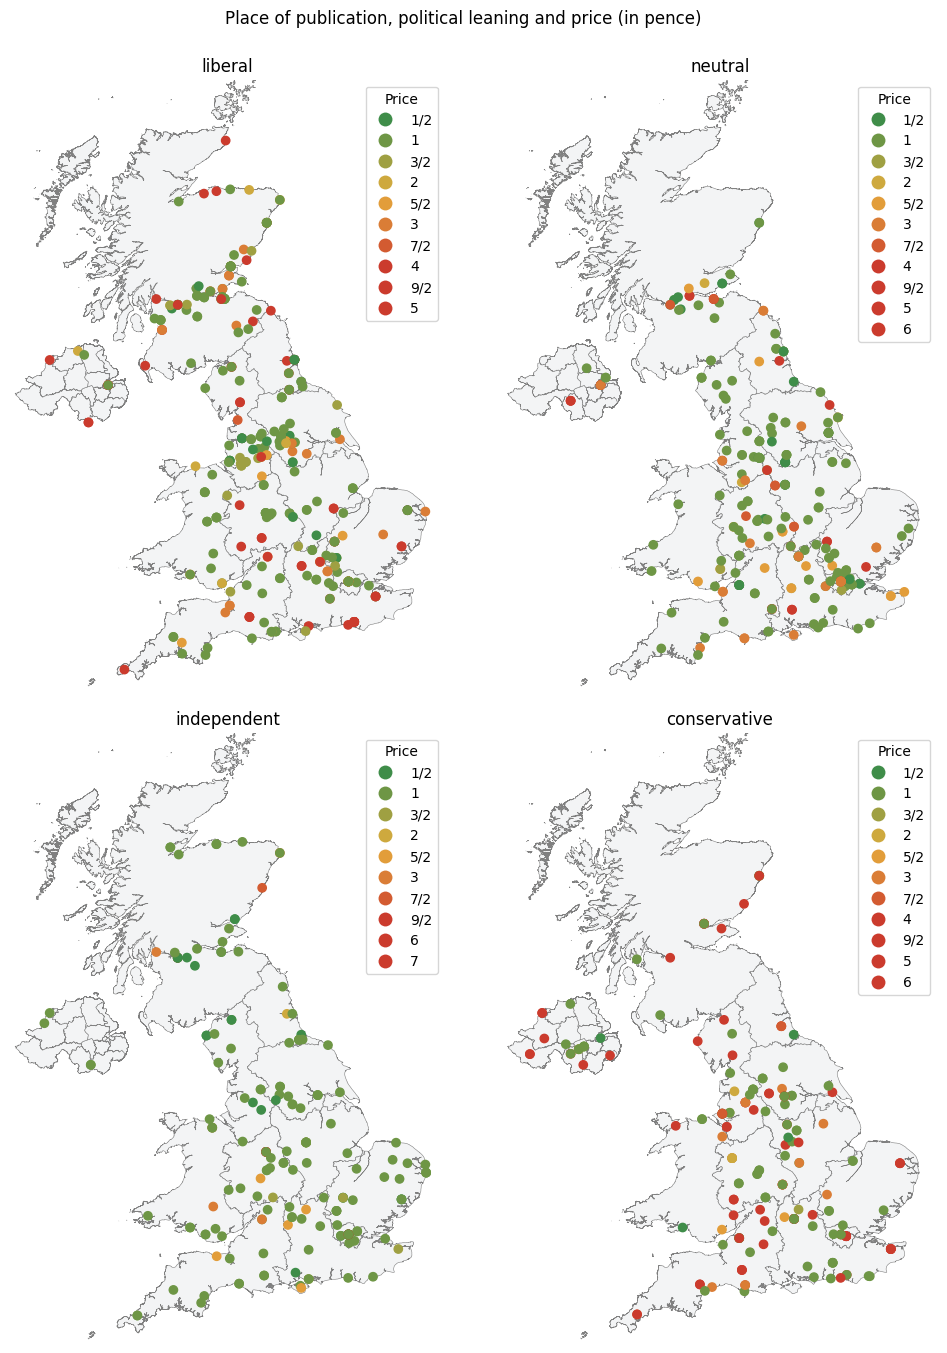

In [108]:
from  matplotlib.colors import LinearSegmentedColormap
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,14))
fig.suptitle("Place of publication, political leaning and price (in pence)")
fig.tight_layout()
fig.subplots_adjust(top=0.93)
cmap=LinearSegmentedColormap.from_list('gar',["#3F8D49", "#E6AE3C", "#CB3B2D"], N=256)
plt.setp(ax, xlim=(-8.3, 2.2), ylim=(49.8, 59.4))
vmin = Fraction(0)
vmax = Fraction(7)

def plot_map(political_leaning_label, ax):
    params = {"color": "#f3f4f5", "edgecolor": "grey", "linewidth": 0.4, "aspect": None}
    england.plot(ax=ax, **params)
    wales.plot(ax=ax, **params)
    scotland.plot(ax=ax, **params)
    northern_ireland.plot(ax=ax, **params)

    geo_df[geo_df['political_leaning_label'] == political_leaning_label].plot(ax=ax, column="price", cmap=cmap, vmin=vmin, vmax=vmax, legend=True, aspect=None)
    ax.title.set_text(political_leaning_label)
    leg = ax.get_legend()
    leg.set_title("Price")
    ax.axis('off')

political_leanings = ["liberal", "neutral", "independent", "conservative"]

handles = []; labels = []
for i, ax in enumerate(fig.axes):
    plot_map(political_leanings[i], ax)

Note that this data visualisation does not capture the temporal dimension. Prices and political leanings in the plot are snapshots taken from the earliest edition of Mitchell's Newspaper Press Directory published after the date at which each corresponding newspaper title was established. Therefore the data above do not correspond to a single, common calendar year.

## 6. Construct samples

This section contains some examples of how to create subsamples of the newspaper metadata. Three types of sample are considered:
1. **Filtered samples**, obtained via simple filtering with respect to the values of one or more variables.
2. **Impartial samples**, obtained by random selection which preserves multivariate distributions between variables.
3. **Prescriptive samples**, obtained by random selection while prescribing a desired distribution with respect to particular variables.

### Filtered samples

We begin with some simple examples of filtering the table of newspaper issues by time period and/or place of publication.

First we filter on the `date` column to obtain all of the newspaper issues from the 1850s:

In [109]:
issues_1850s = issues.query('18500101 <= date < 18591231').sort_values('date')
display(issues_1850s)

,issue_id,issue_code,date,data_provider,newspaper_id,publication_code
1368839,121000,0001260-18500101,1850-01-01,FindMyPast,92,0001260
1195672,1849546,0000950-18500101,1850-01-01,FindMyPast,1220,0000950
...,...,...,...,...,...,...
517481,915247,0000237-18591230,1859-12-30,FindMyPast,689,0000237
672656,1281115,0000296-18591230,1859-12-30,FindMyPast,916,0000296


The filtered tables take up much less space in memory, so we can join it to the TITLES table to add additional columns of metadata.

To do this, we use the [`pd.merge`](https://pandas.pydata.org/docs/reference/api/pandas.merge.html) function, and join on the three columns that are common to both tables: the `publication_code`, `newspaper_id` and `data_provider`.

In [110]:
issues_1850s = pd.merge(issues_1850s, titles, how='left', on=['publication_code', 'newspaper_id', 'data_provider'])
display(issues_1850s)

,issue_id,issue_code,date,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,digitisation_software,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
0,121000,0001260-18500101,1850-01-01,FindMyPast,92,0001260,The Public ledger,"London, England",alto,CCS docWorks/METAe Version 6.9-1,...,NaN,[],NaN,54,['3 ½'],3 ½,1759,Daily,[],[]
1,1849546,0000950-18500101,1850-01-01,FindMyPast,1220,0000950,"The Cumberland Pacquet, and Ware's Whitehaven ...","Whitehaven, Cumbria, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,67,['4 ½ d'],4 ½ d,"October 20 , 1774",Tuesday,[],['Robert Gibson']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159289,915247,0000237-18591230,1859-12-30,FindMyPast,689,0000237,"The Lincoln, Rutland and Stamford Mercury, etc","Stamford, Lincolnshire, England",alto,CCS docWORKS/METAe Version 6.6-0,...,37,['liberal'],liberal,67,['4 ½ d'],4 ½ d,1695,Friday,[],['Richard Newcomb']
159290,1281115,0000296-18591230,1859-12-30,FindMyPast,916,0000296,"Dundee, Perth, and Cupar Advertiser","Dundee, Tayside, Scotland",alto,CCS docWorks/METAe Version 6.8-1,...,37,['liberal'],liberal,59,['3d'],3d,1801,Tuesday<SEP>Friday,['A Company of Residents'],['Alexander Macdonald']


In the next example, we filter on the `historic_county_label` column to obtain all of the issues from the historic county of Dorset:

In [111]:
titles_dorset = titles[titles['historic_county_label'] == 'Dorset']
issues_dorset = issues[issues['publication_code'].isin(titles_dorset['publication_code'])]
issues_dorset = pd.merge(issues_dorset, titles, how='left', on=['publication_code', 'newspaper_id', 'data_provider'])
display(issues_dorset)


,issue_id,issue_code,date,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,digitisation_software,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
0,1437017,0000408-18240108,1824-01-08,FindMyPast,1008,0000408,"Dorset County Chronicle, etc","Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,88,['5d'],5d,"January 4 , 1821",Thursday,[],['George Simonds']
1,1436062,0000408-18240115,1824-01-15,FindMyPast,1008,0000408,"Dorset County Chronicle, etc","Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,88,['5d'],5d,"January 4 , 1821",Thursday,[],['George Simonds']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13221,2421874,0003091-18860504,1886-05-04,Living with Machines,1489,0003091,The Dorset County Express and Agricultural Gaz...,"Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 7.1-0,...,17,"['liberal', 'conservative']",conservative,59,"['3d', '4d']",3d,"Oct . 9 , 1855",Tuesday,[],['ChaS. Atkins']
13222,2421599,0003091-18860511,1886-05-11,Living with Machines,1489,0003091,The Dorset County Express and Agricultural Gaz...,"Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 7.1-0,...,17,"['liberal', 'conservative']",conservative,59,"['3d', '4d']",3d,"Oct . 9 , 1855",Tuesday,[],['ChaS. Atkins']


Combining the last two examples, we obtain all of the newspaper issues from the historic county of Dorset published during the 1850s:

In [112]:
issues_dorset_1850s = issues_dorset.query('18500101 <= date < 18591231').sort_values('date')
display(issues_dorset_1850s)

,issue_id,issue_code,date,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,digitisation_software,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
1237,1436245,0000408-18500103,1850-01-03,FindMyPast,1008,0000408,"Dorset County Chronicle, etc","Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,88,['5d'],5d,"January 4 , 1821",Thursday,[],['George Simonds']
3571,1438482,0000411-18500105,1850-01-05,FindMyPast,1012,0000411,"The Western Flying Post; or, Sherborne and Yeo...","Sherborne., Dorset, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,67,['4 ½ d'],4 ½ d,1736,Saturday,[],"['William Webb Penny', 'John Vicary']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1763,1435584,0000408-18591229,1859-12-29,FindMyPast,1008,0000408,"Dorset County Chronicle, etc","Dorchester, Dorset, England",alto,CCS docWorks/METAe Version 6.7-1,...,17,['conservative'],conservative,88,['5d'],5d,"January 4 , 1821",Thursday,[],['George Simonds']
9026,932518,0002325-18591229,1859-12-29,FindMyPast,701,0002325,"The Poole and South-Western Herald, etc","Poole, Dorset, England",alto,CCS docWorks/METAe Version 6.9-2,...,84,['whig'],whig,88,['5d'],5d,"April 9 , 1846",Thurs<SEP>-<SEP>day,[],"['M. . Welch H. M. Aldridge', 'James Tribbett']"


The next example filters on the `data_provider` column to produce a table of open access newspaper issues. As explained above, these are the newspapers for which the data provider is either `Living with Machines` or `Heritage Made Digital`.

In [113]:
# All open access newspaper issues:
oa_data_providers = ('Living with Machines', 'Heritage Made Digital')
issues_oa = issues[issues['data_provider'].isin(oa_data_providers)]
issues_oa = pd.merge(issues_oa, titles, how='left', on=['publication_code', 'newspaper_id', 'data_provider'])

# Insert a new column for the year of publication:
issues_oa.insert(3, "year", [d.year for d in issues_oa['date']])
display(issues_oa)

,issue_id,issue_code,date,year,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
0,1910106,0002083-18530924,1853-09-24,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
1,1910288,0002083-18530926,1853-09-26,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107710,2425751,0003548-19040630,1904-06-30,1904,Living with Machines,1504,0003548,"New Tredegar, Bargoed & Caerphilly Journal","Bedwellty, Gwent, Wales",alto,...,NaN,[],NaN,173,['½ d'],½ d,1904,Saturdays,[],['Percy S. Phillips']
107711,2425752,0003548-19040707,1904-07-07,1904,Living with Machines,1504,0003548,"New Tredegar, Bargoed & Caerphilly Journal","Bedwellty, Gwent, Wales",alto,...,NaN,[],NaN,173,['½ d'],½ d,1904,Saturdays,[],['Percy S. Phillips']


### Random samples

Next we'll create some random samples using the [`subsamplr`](https://github.com/Living-with-machines/subsamplr) tool, which makes it easy to construct samples that either reflect the underlying data, or prescribe the joint distributions of particular variables of interest.

First we install `subsamplr` from GitHub:

In [114]:
%pip install --upgrade -q git+https://github.com/Living-with-machines/subsamplr@main


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Next we specify a set of variables to be used for sampling (referred to as "dimensions").

As an example, we shall construct subsamples from the table of open access newspaper issues, taking into account the `year` and `political_leaning_label` variables.

The `year` is a discrete variable. We must specify its type (integer), the discretisation size (one in this case), the variable range of interest (i.e. min & max) and the "bin size", which refers to the size of the bins into which all of the table rows will be assigned. The sampling procedure involves the random selection of a bin followed by the random selection of a row inside the bin. Here we specify a bin size of 10, meaning that each bin corresponds to a decade during the `year` range.

The `political_leaning_label` is a categorical variable. We must specify its type (string) and the list of categories of interest.

Any table rows whose values fall outside of the specified range (for a discrete variable) or list of categories (for a categorical variable) will be ignored when drawing the sample. For instance, here we have omitted the `independent` political leaning from the list of categories, so no articles from independent-leaning newspapers will be selected.

**Note:** In addition to discrete and categorical variables, `subsamplr` also supports continuous numerical variables (for example, see the `ocr_quality_mean` variable defined [here](https://github.com/Living-with-machines/subsamplr/blob/main/examples/example_database_subsampling.ipynb)).

In [115]:
import yaml
from io import StringIO
config_str = """
variables:
    - {name: 'year', class: 'discrete', type: 'int', min: 1850,
        max: 1899, discretisation: 1, bin_size: 10}
    - {name: 'political_leaning_label', class: 'categorical', type: 'str',
        categories: ['liberal', 'neutral', 'conservative']}
"""
config = yaml.safe_load(StringIO(config_str))

Next we construct the collection of bins, given the above configuration, and assign the table rows (or sampling "units") to those bins.

We identify each row (or "unit") by the `issue_id` variable, which is a unique identifier for the rows in the `issues_oa` table.

In [116]:
from subsamplr import BinCollection, UnitGenerator
bins = BinCollection.construct(config, track_exclusions=True)
generator = UnitGenerator.generate_units(
	issues_oa, unit_id="issue_id", variables=bins.dimensions)
units = list(generator)
for unit, values in units:
    bins.assign_to_bin(unit, values)

To summarise the binning process, we had 107,712 rows in our original table of open access newspaper issues. From those rows 47,355 sampling units were constructed. The other 60,357 had missing values in the `political_leaning_label` column.

Based on the configuration above, 28,708 have been assigned to bins for sampling, and the other 18,647 were excluded because their values fall outside of the specified variable ranges.

In [117]:
print(f"Open access issues: \t{len(issues_oa)}")
print(f"Sampling units: \t{len(units)}")
print(f"Binned: \t\t{bins.count_units()}")
print(f"Excluded: \t\t{bins.count_exclusions()}")

Open access issues: 	107712
Sampling units: 	47355
Binned: 		28708
Excluded: 		18647


#### Impartial samples

Before drawing a random sample, it is advisable to set a random seed. The seed is an arbitrary number used to initialise the random number generator in [`numpy`](https://numpy.org/), so that an identical sample can be generated in future by specifying the same seed.

In [118]:
seed = 654321
from numpy.random import seed as npseed
npseed(seed)

Drawing samples from our populated collection of bins is straightforward. Here we extract a sample of 1000 open access newpspaper issues:

In [119]:
k = 1000
sample_units = bins.select_units(k)
issues_sample = issues_oa[issues_oa['issue_id'].isin(sample_units)]
display(issues_sample)

,issue_id,issue_code,date,year,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
35,1910315,0002083-18531105,1853-11-05,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
53,1910121,0002083-18531126,1853-11-26,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107584,2425574,0003539-18650211,1865-02-11,1865,Living with Machines,1501,0003539,The Miner and Workman's Advocate,"London, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"March 13 , 1863",Saturday,[],['W. Whitehorn']
107604,2425651,0003539-18650708,1865-07-08,1865,Living with Machines,1501,0003539,The Miner and Workman's Advocate,"London, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"March 13 , 1863",Saturday,[],['W. Whitehorn']


The political leanings in the sample are similar to those in the full table of open access issues:

In [120]:
print(issues_sample['political_leaning_label'].value_counts().reindex().to_string())

political_leaning_label
liberal         492
neutral         369
conservative    139


In [121]:
print(issues_oa['political_leaning_label'].value_counts(dropna=False).reindex().to_string())

political_leaning_label
NaN             60357
liberal         19017
neutral         13725
conservative     8785
independent      5755
radical            73


#### Prescriptive samples

 Now we construct a sample in which the distributions of the configured variables are deliberately controlled.

The specified range of values for the `year` variable (1850-1859) is split across five bins, one for each decade.

The specified range of values for the `political_leaning_label` variable is split across three categories: 'liberal', 'neutral' and 'conservative'.

We must prescribe (relative) weights for each variable and for each bin. Therefore we define our `weights` as a tuple of the same length as `bins.dimensions`, each element being itself a list of weights, one for each bin.

Here we weight the last two decades twice as heavily as the first three decades, and we assign equal weight to all three political leaning categories.

In [122]:
year_weights = [1, 1, 1, 2, 2]
political_leaning_label_weights = [1, 1, 1]
weights = (year_weights, political_leaning_label_weights)

Once again we set the random seed (for reproducibility), and then call `select_units()` to generate the sample, this time passing in the weights.

In [123]:
npseed(seed)
sample_units = bins.select_units(k, weights=weights)
issues_sample = issues_oa[issues_oa['issue_id'].isin(sample_units)]
display(issues_sample)

,issue_id,issue_code,date,year,data_provider,newspaper_id,publication_code,newspaper_title,location,xml_flavour,...,political_leaning_id,political_leaning_raw,political_leaning_label,price_id,price_raw,price_label,date_established_raw,day_of_publication_raw,organisations,persons
30,1910108,0002083-18531029,1853-10-29,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
51,1910245,0002083-18531124,1853-11-24,1853,Heritage Made Digital,1251,0002083,The Northern Daily Times,"Liverpool, Merseyside, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"Sept , 24 , 1843",NaN,[],['Charles Willmer']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107605,2425551,0003539-18650715,1865-07-15,1865,Living with Machines,1501,0003539,The Miner and Workman's Advocate,"London, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"March 13 , 1863",Saturday,[],['W. Whitehorn']
107606,2425599,0003539-18650722,1865-07-22,1865,Living with Machines,1501,0003539,The Miner and Workman's Advocate,"London, England",alto,...,43,['neutral'],neutral,59,"['2d', '3d']",3d,"March 13 , 1863",Saturday,[],['W. Whitehorn']


This time all three political leanings are represented approximately equally, because the sample was selected according to the prescribed uniform distribution on that dimension.

In [124]:
print(issues_sample['political_leaning_label'].value_counts().reindex().to_string())

political_leaning_label
liberal         342
conservative    338
neutral         320


On the time axis, the weights were skewed towards to last two decades of the century.

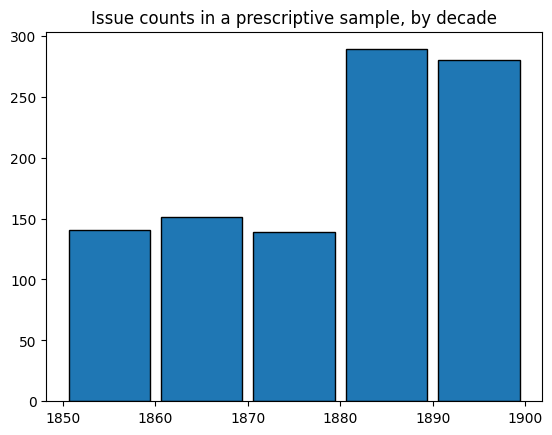

In [125]:
plt.hist(issues_sample['year'], bins=[1850, 1860, 1870, 1880, 1890, 1900], rwidth=0.88, edgecolor='black')
plt.title('Issue counts in a prescriptive sample, by decade');

## 7. Full text access

Now that we have our sample of newspaper issues, from the open access collections, we can download the full text content of a selection of articles contained in those issues.

Let's begin by identifying the longest articles, by word count, from each of the issues in the sample.

In [126]:
# Find the row indices of the longest articles:
idx = items[items['issue_id'].isin(issues_sample['issue_id'])].groupby('issue_id')['word_count'].idxmax()
items_sample = items.loc[idx]
display(items_sample)


,item_id,item_code,word_count,ocr_quality_mean,issue_id,date,newspaper_id
3515,199446985,0002083-18560722-art0042,5326,0.9382,1910054,1856-07-22,1251
7997,199430811,0002083-18560516-art0034,13970,0.8777,1910099,1856-05-16,1251
...,...,...,...,...,...,...,...
9318688,223001959,0003539-18631212-art0015,7862,0.9685,2425634,1863-12-12,1501
9319089,223000616,0003539-18640723-art0019,8878,0.9450,2425641,1864-07-23,1501


### Download full text

Like the newspaper metadata, article full text data is stored in a publicly-accessible record on the Zenodo research repository.

These data are stored in zip files, one for each newspaper title, with filenames of the form `XXXXXXX_plaintext.zip`, where `XXXXXXX` is the publication code for the particular title.

The following helper functions will be used to download these zip archives and store then in the `./data` directory (under a different subdirectory for each data provider):

In [127]:
# Gets a short acronym for the data provider for a given publication.
def provider(publication_code):
    data_provider = titles[titles.publication_code == publication_code].data_provider.item()
    return ''.join([w[0] for w in data_provider.split()]).lower()

# Gets the local relative path to the article full text (zip file) for a given publication.
def fulltext_zip(publication_code):
    return Path(f"./data/{provider(publication_code)}-alto2txt/{publication_code}_plaintext.zip")

# Returns the cloud storage location of the article full text (zip file) for a given publication.
def fulltext_url(publication_code):
    url = "https://zenodo.org/records/AAAAAAAA/files/{FILENAME}?download=1" # TODO: add Zenodo record ID when published.
    return url.replace("{FILENAME}", fulltext_zip(publication_code).name)

# Downloads a zip file containing article full text for a given collection of publications.
def download_fulltext(publication_code):
    if not os.path.exists(fulltext_zip(publication_code)):
        urlretrieve(fulltext_url(publication_code), fulltext_zip(publication_code))

Using the `download_fulltext` function we can download all of the titles in our sample of newspaper items. 

However these files can be quite large so, to demonstrate the process, we will discard all except the first 50 rows of the sample:

In [128]:
# Reduce the sample to 50 newspaper items, to save time when downloading.
# Skip this line if you want to download full text for the complete sample.
items_sample = items_sample.head(50)

We extract the publication code as the first seven characters of the `item_code`, and discard any duplicates.

In [129]:
pub_codes = {item_code[:7] for item_code in items_sample['item_code']}
pub_codes

{'0002083', '0002085', '0002088'}

Let's go ahead and download the full text files for each of these publications (this process may take several minutes):

In [130]:
for pub_code in tqdm(pub_codes):
    download_fulltext(pub_code)

100%|██████████| 3/3 [00:00<00:00, 903.69it/s]


### Extract article text

Next we define functions to read the full text content from the downloaded zip archives.

In [131]:
# Returns the path to the full text file, for a particular newspaper item, inside a zip archive.
def item_path(item_code):
    return Path(f"{item_code[:7]}/{item_code[8:12]}/{item_code[12:16]}/{item_code.replace('-', '_')}.txt")

# Reads the full text for a given newspaper item.
def read_item(item_code):
    pub_code = item_code[:7]
    if not os.path.exists(fulltext_zip(pub_code)):
        raise(FileNotFoundError(f"Zip archive not found for publication {pub_code}. Use download_fulltext()."))
    with zipfile.ZipFile(fulltext_zip(pub_code)) as z:
        return z.read(str(item_path(item_code)))

# Returns a dictionary of newspaper item full text, keyed by the item_code.
def read_items(items_sample):
    items = {}
    for index, row in tqdm(items_sample.iterrows()):
        items[row['item_code']] = read_item(row['item_code'])
    return items

Finally, we read all of the items in our sample:

In [132]:
items_text = read_items(items_sample)

50it [00:13,  3.83it/s]


This produces a dictionary of key-value pairs. For each item, the key is the `item_code` and value is the full text content:

In [133]:
example_item_code = list(items_text.keys())[0]
print(f"Full text for item {example_item_code}:")
items_text[example_item_code]

Full text for item 0002083-18560722-art0042:


b'--LIVERPOOL, TUESDAY\xe2\x80\xa2\n\nMONETARY AND COMMERCIAL\n\nLIVERPOOL, MONDAY EVENING\n\nThere has been a fair amount of business done\nin the Cotton Market .to-day, the sales amounting\nto 8,000 bales, of which 2,000 have been taken for\nspeculation and export. Prices remain without\nchange.\nThe Liverpool Share Market opened steady with\na firm tone, and continued so to the close, when\nprices stood as follows :\xe2\x80\x94Aberdeen, 141 141.\nChester and Birkenhead, 161 17. Caledonian, 301-\n301. Chester and Holyhead, 178 171. Eastern\nCounties; lot 10 5-16. East Lancashire, 211 211.\nGreat Northern, 23 24. Ditto A, 91 91. Great\nWestern, 61162. Lancashire and Yorkshire Stock,\n984,- 981. Liverpool, Crosby, and Southport, 1811,-\n19. London and North Western Stock, 1081 1081\nManchester, Sheffield, and Lincoln, 331331- Ditto\nNew 6 per cent. Pref., 13-16 15-16 p. Ditto Pref., 12\n11-16 12 13-16. Midland Stock, 831 831. North\nBritish, 98 91 North Staffordshire, 41- 4d. South\nEa

Here is the complete list of items:

In [134]:
items_text

{'0002083-18560722-art0042': b'--LIVERPOOL, TUESDAY\xe2\x80\xa2\n\nMONETARY AND COMMERCIAL\n\nLIVERPOOL, MONDAY EVENING\n\nThere has been a fair amount of business done\nin the Cotton Market .to-day, the sales amounting\nto 8,000 bales, of which 2,000 have been taken for\nspeculation and export. Prices remain without\nchange.\nThe Liverpool Share Market opened steady with\na firm tone, and continued so to the close, when\nprices stood as follows :\xe2\x80\x94Aberdeen, 141 141.\nChester and Birkenhead, 161 17. Caledonian, 301-\n301. Chester and Holyhead, 178 171. Eastern\nCounties; lot 10 5-16. East Lancashire, 211 211.\nGreat Northern, 23 24. Ditto A, 91 91. Great\nWestern, 61162. Lancashire and Yorkshire Stock,\n984,- 981. Liverpool, Crosby, and Southport, 1811,-\n19. London and North Western Stock, 1081 1081\nManchester, Sheffield, and Lincoln, 331331- Ditto\nNew 6 per cent. Pref., 13-16 15-16 p. Ditto Pref., 12\n11-16 12 13-16. Midland Stock, 831 831. North\nBritish, 98 91 North Sta

And we can merge the extracted text into the dataframe of sample items, to work with the metadata and article text together:

In [135]:
items_sample['text'] = items_sample['item_code'].map(items_text)
items_sample

,item_id,item_code,word_count,ocr_quality_mean,issue_id,date,newspaper_id,text
3515,199446985,0002083-18560722-art0042,5326,0.9382,1910054,1856-07-22,1251,"b'--LIVERPOOL, TUESDAY\xe2\x80\xa2\n\nMONETARY..."
7997,199430811,0002083-18560516-art0034,13970,0.8777,1910099,1856-05-16,1251,"b'AMERICA.\n\nSOUTHAMPTON, THURSDAY. 2\nThe Un..."
...,...,...,...,...,...,...,...,...
233581,199703179,0002088-18511209-art0143,7500,0.8919,1911691,1851-12-09,1254,"b'"" Defiez-vows des belles paroles des gens qn..."
246873,199769164,0002088-18500507-art0042,8396,0.7899,1911765,1850-05-07,1254,"b'Tlid LIVERPOOL SUNDA IL\n\ncretions, they we..."


## 8. Summary

To summarise, we have:
- downloaded tables of newspaper metadata
- explored the landscape of historical newspapers acquired by the Living with Machines project
- visualised the metadata in a geospatial plot
- constructed a sample of open access newspaper issues, and identified the longest article in each of those issues
- downloaded zip files containing the full text content of a selection of titles
- extracted the full text for each article in our sample, ready for further analysis.